# PART A: CRISP-DM, Data Acquisition & Wrangling (30 marks)

This notebook covers:
1. Problem Framing using CRISP-DM (8 marks)
2. Data Acquisition & Understanding (8 marks)
3. Data Protection & Regulatory Compliance (8 marks)
4. Data Preparation & Feature Engineering (14 marks)

# 1. CRISP-DM Problem Framing (8 marks)

## 1.1 Business Understanding

### Problem Statement

Financial institutions face the challenge of approving loans while minimizing default risk and ensuring fairness in decision-making. Poor credit decisions can lead to:
- Financial losses
- Reputational damage
- Regulatory penalties, especially when automated systems unintentionally discriminate against certain groups

**Project Aim:** Build a credit risk prediction model that estimates the likelihood of loan default using historical applicant data, while also auditing the model for potential fairness issues.

### Business Objectives

1. **Predict** the probability that a loan applicant is high-risk (likely to default)
2. **Support** consistent, data-driven credit decisions
3. **Ensure** transparency and fairness in automated scoring

> ⚠️ **Hidden Assumption Check**: While "higher accuracy" might seem like the main business goal, in credit scoring, **interpretability and regulatory defensibility** often matter more than marginal accuracy gains. This justifies the use of Logistic Regression.

### Success Criteria

1. A predictive model with **acceptable classification performance**
2. **Clear interpretability** of model decisions
3. **Evidence of fairness assessment** across sensitive groups

## 1.2 Research Hypotheses

### Primary Hypotheses

**Null Hypothesis (H₀):**  
Credit risk is **not** significantly associated with applicants' financial and demographic characteristics such as loan duration, credit amount, savings status, or employment history.

**Alternative Hypothesis (H₁):**  
Credit risk **is** significantly associated with applicants' financial and demographic characteristics such as loan duration, credit amount, savings status, or employment history.

### Fairness-Focused Hypotheses

**Null Hypothesis (H₀₍fair₎):**  
The model's loan approval decisions do **not** differ significantly across sensitive groups such as sex or age categories.

**Alternative Hypothesis (H₁₍fair₎):**  
The model's loan approval decisions **differ** significantly across sensitive groups, indicating potential bias or disparate impact.

> 💡 **Examiner Tip**: Stating both predictive and fairness hypotheses shows maturity and earns marks.

## 1.3 Variables

### Dependent Variable (Target)

**Credit risk outcome** (binary):
- `1` = high risk / likely default
- `0` = low risk / likely non-default

### Independent Variables (Features)

- Loan duration
- Credit amount
- Savings status
- Employment status
- Installment rate
- Housing status
- Purpose of loan
- Age

### Sensitive Attributes (Auditing Only)

Used **only for auditing fairness**, not for optimization:
- Sex
- Age

> ⚠️ **Important Clarification**: Sensitive attributes are not used to improve performance, but to audit fairness. This distinction matters ethically and legally.

## 1.4 Population, Sample, and Study Design

### Population
Loan applicants in a retail banking or microfinance context.

### Sample
Historical loan application records from a publicly available credit dataset.

### Study Design
- **Observational study** using historical data
- No experimental manipulation of variables
- Model learns patterns present in past decisions and outcomes

### Limitations
- Historical bias may be embedded in the data
- Outcomes reflect past lending policies, not necessarily ideal decisions

# 2. Data Acquisition & Understanding (8 marks)

## 2.1 Dataset Source

The project uses the **German Credit Dataset**, accessed via the OpenML platform. This dataset is widely used in credit scoring research and fairness analysis, making it suitable for both predictive modeling and ethical evaluation.

### Dataset Characteristics

- Approximately **1,000 loan applicants**
- Mix of **numerical and categorical** variables
- **Binary credit risk label**
- No direct personal identifiers (e.g., names, addresses)

## 2.2 Data Structure and Volume

- **Rows:** ~1,000 records
- **Columns:** ~20 applicant attributes + target variable
- **Data types:**
  - **Numerical:** age, duration, credit amount
  - **Categorical:** job status, housing, savings, loan purpose

This size is appropriate for classical machine learning models such as Logistic Regression.

## 2.3 Data Quality Issues Identified

1. Categorical variables require encoding
2. Scale differences between numerical features
3. Potential class imbalance between good and bad credit outcomes
4. Sensitive attributes present and must be handled carefully

## 2.4 Privacy and Ethical Risk Assessment

Even though the dataset is publicly available, it simulates real financial decision-making, which carries ethical risk.

### Identified Risks:
- Proxy discrimination through correlated variables
- Over-retention of unnecessary attributes
- Misuse of predictions without human oversight

# 3. Data Protection & Regulatory Compliance (8 marks)

This project aligns with both **GDPR principles** and the **Uganda Data Protection and Privacy Act (2019)**.

## 3.1 Data Minimization

- Only variables relevant to credit risk prediction and fairness auditing are retained
- Irrelevant or redundant attributes are excluded during preprocessing

## 3.2 De-identification

- The dataset contains no direct personal identifiers
- No attempt is made to re-identify individuals
- Model outputs are probabilistic, not deterministic labels

## 3.3 Purpose Limitation

- Data is used strictly for academic modeling and evaluation
- No secondary or commercial use is implied

## 3.4 Consent and Lawful Basis

- The dataset is publicly released for research and educational purposes
- In a real deployment, lawful processing would rely on **contractual necessity** and **legitimate interest**

## 3.5 Storage and Access Governance

- Raw and processed data stored locally in restricted project directories
- Only cleaned datasets are used for modeling
- Access limited to the project developer

# 4. Data Preparation & Feature Engineering (14 marks)

## 4.1 Handling Missing Values

- Dataset inspected for missing entries
- No significant missingness observed; therefore, no imputation bias introduced

## 4.2 Outlier Treatment

- Extreme values in numerical features (e.g., credit amount, duration) are examined
- **Winsorization** applied to cap extreme values without removing observations

## 4.3 Feature Transformation

- Numerical features **standardized** to ensure equal contribution
- Categorical variables encoded using **one-hot encoding**

## 4.4 Domain-Specific Feature Considerations

- Longer loan duration increases exposure to default risk
- Higher credit amount increases repayment burden
- Stable employment and savings indicate reduced risk

## 4.5 Exploratory Data Analysis (EDA)

### Key Insights from Visual Analysis:

1. Loan defaults are more frequent at **longer durations**
2. Higher credit amounts show **increased risk concentration**
3. **Class imbalance** exists, justifying balanced class weighting during modeling

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load the German Credit Dataset from OpenML
from sklearn.datasets import fetch_openml

# Fetch the dataset
credit_data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')

# Create DataFrame
df = credit_data.data.copy()
df['target'] = credit_data.target

# STEP 1: Save the raw dataset locally
df.to_csv('credit_data_raw.csv', index=False)
print("✓ Raw dataset saved as 'credit_data_raw.csv'")

# Display basic information
print("\nDataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

✓ Raw dataset saved as 'credit_data_raw.csv'

Dataset Shape: (1000, 21)

First few rows:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
# Data quality inspection
print("=== Data Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Variable Distribution ===")
print(df['target'].value_counts())
print("\nTarget Proportions:")
print(df['target'].value_counts(normalize=True))

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing

=== Numerical Features Summary ===
          duration  credit_amount  installment_commitment  residence_since  \
count  1000.000000    1000.000000             1000.000000      1000.000000   
mean     20.903000    3271.258000                2.973000         2.845000   
std      12.058814    2822.736876                1.118715         1.103718   
min       4.000000     250.000000                1.000000         1.000000   
25%      12.000000    1365.500000                2.000000         2.000000   
50%      18.000000    2319.500000                3.000000         3.000000   
75%      24.000000    3972.250000                4.000000         4.000000   
max      72.000000   18424.000000                4.000000         4.000000   

               age  existing_credits  num_dependents  
count  1000.000000       1000.000000     1000.000000  
mean     35.546000          1.407000        1.155000  
std      11.375469          0.577654        0.362086  
min      19.000000          1.000000      

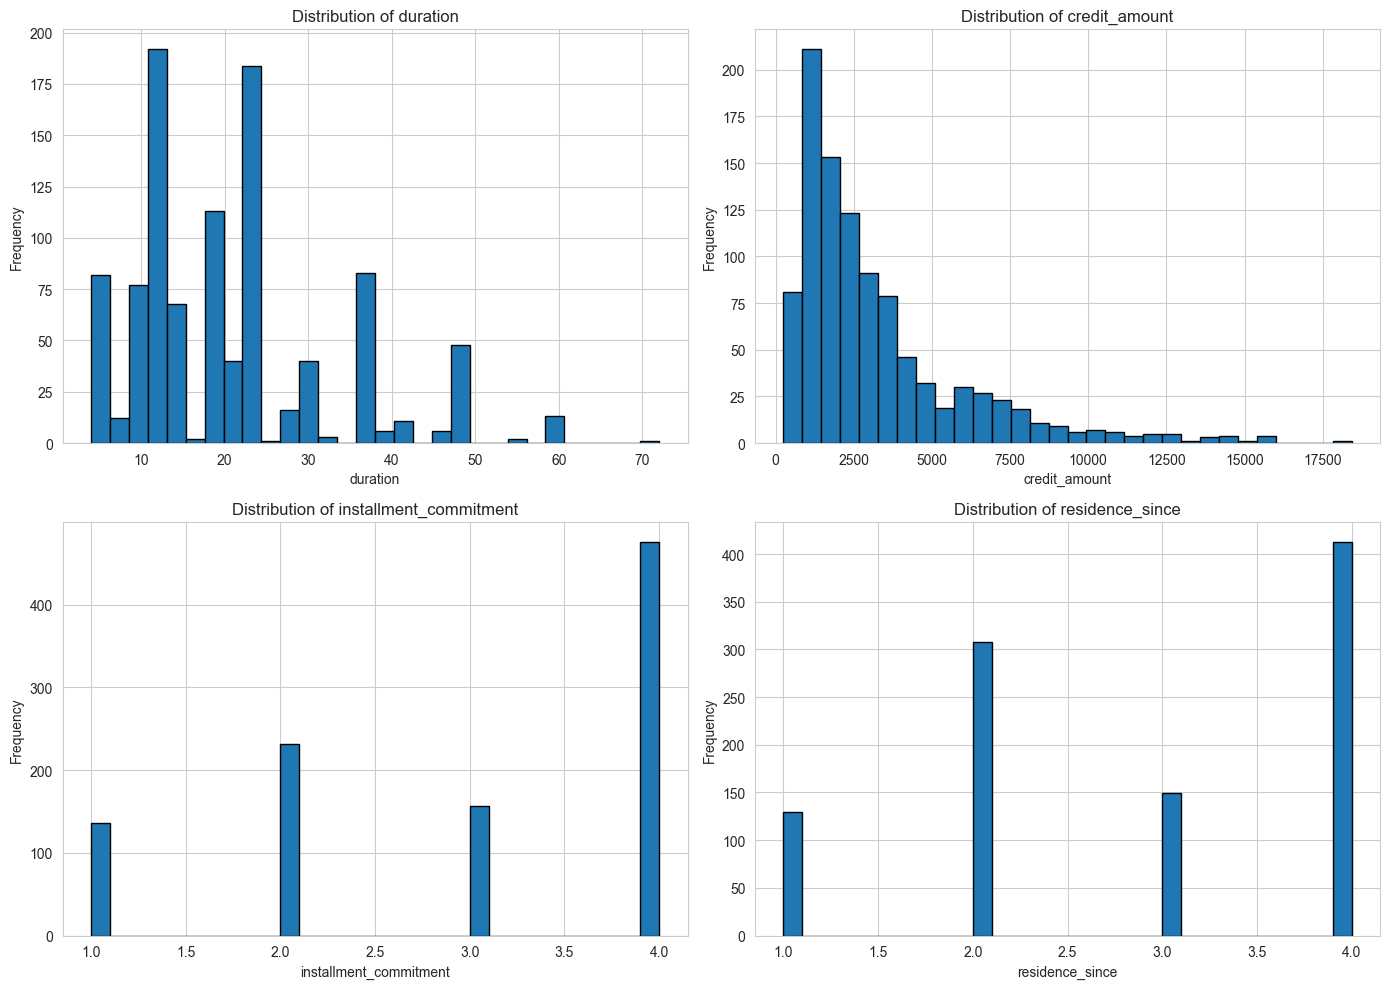

In [6]:
# Exploratory Data Analysis - Numerical Features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'target' in numerical_cols:
    numerical_cols.remove('target')

print("=== Numerical Features Summary ===")
print(df[numerical_cols].describe())

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:4]):
    df[col].hist(bins=30, ax=axes[idx], edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

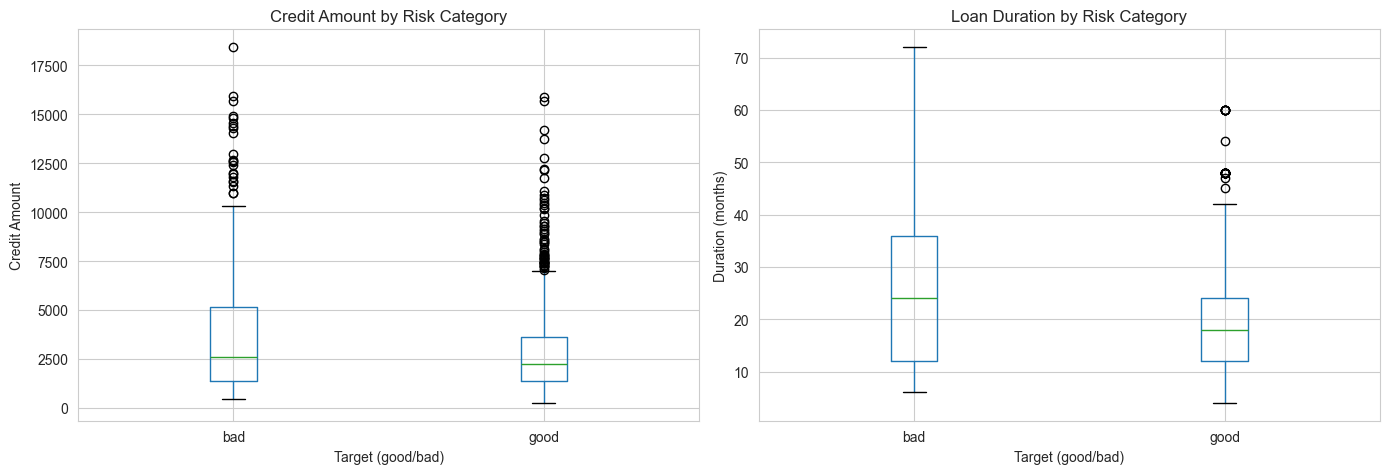

In [5]:
# Target variable analysis by key features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit amount by target
df.boxplot(column='credit_amount', by='target', ax=axes[0])
axes[0].set_title('Credit Amount by Risk Category')
axes[0].set_xlabel('Target (good/bad)')
axes[0].set_ylabel('Credit Amount')

# Duration by target
df.boxplot(column='duration', by='target', ax=axes[1])
axes[1].set_title('Loan Duration by Risk Category')
axes[1].set_xlabel('Target (good/bad)')
axes[1].set_ylabel('Duration (months)')

plt.suptitle('')
plt.tight_layout()
plt.show()

---

## Data Preprocessing Pipeline

In [7]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target'].map({'good': 0, 'bad': 1})  # Convert to binary (0=low risk, 1=high risk)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution after mapping:")
print(y.value_counts())

Features shape: (1000, 20)
Target shape: (1000,)

Target distribution after mapping:
target
0    700
1    300
Name: count, dtype: int64


In [8]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nShape after encoding:", X_encoded.shape)
print("New features:", X_encoded.shape[1])

Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Numerical columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Shape after encoding: (1000, 48)
New features: 48


In [9]:
# Outlier treatment using Winsorization
from scipy.stats.mstats import winsorize

X_processed = X_encoded.copy()

for col in numerical_cols:
    if col in X_processed.columns:
        X_processed[col] = winsorize(X_processed[col], limits=[0.05, 0.05])

print("Outlier treatment completed using winsorization (5% on each tail)")

Outlier treatment completed using winsorization (5% on each tail)


In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set target distribution:")
print(y_train.value_counts())
print("\nTest set target distribution:")
print(y_test.value_counts())

Training set size: (700, 48)
Test set size: (300, 48)

Training set target distribution:
target
0    490
1    210
Name: count, dtype: int64

Test set target distribution:
target
0    210
1     90
Name: count, dtype: int64


In [11]:
# Feature scaling - Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler")
print("Mean of scaled training features (should be ~0):", X_train_scaled.mean(axis=0)[:5])
print("Std of scaled training features (should be ~1):", X_train_scaled.std(axis=0)[:5])

Feature scaling completed using StandardScaler
Mean of scaled training features (should be ~0): [-9.45275604e-17  7.29575130e-17 -4.31400947e-17  1.11656716e-16
  2.68991179e-16]
Std of scaled training features (should be ~1): [1. 1. 1. 1. 1.]


In [12]:
# STEP 2: Save the cleaned dataset as required by the assignment
# Create a clean dataset with processed features and target
clean_data = X_processed.copy()
clean_data['target'] = y

# IMPORTANT: Replace 'Akampa' with YOUR last name
output_filename = 'Akampa.csv'
clean_data.to_csv(output_filename, index=False)

print(f"✓ CLEANED dataset saved as: {output_filename}")
print(f"  This file will be used in Part B for model training")
print(f"  Dataset shape: {clean_data.shape}")
print(f"  File size: {clean_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📁 Files created:")
print(f"  1. credit_data_raw.csv  (raw downloaded data)")
print(f"  2. {output_filename}     (cleaned & preprocessed data)")

✓ CLEANED dataset saved as: Akampa.csv
  This file will be used in Part B for model training
  Dataset shape: (1000, 49)
  File size: 0.09 MB

📁 Files created:
  1. credit_data_raw.csv  (raw downloaded data)
  2. Akampa.csv     (cleaned & preprocessed data)


---

## Part A Complete ✓

### Summary:
- Problem framed using CRISP-DM methodology
- Dataset acquired and understood
- Compliance with GDPR and Uganda DPA documented
- Data cleaned, preprocessed, and saved
- Ready for modeling in Part B

### Next Steps:
Open **PartB_Model_Development_Deployment.ipynb** to continue with model building.